# Convergence tests with `pw.x`

We run convergence tests in order to make sure we control and understand the extent to which the numerical approximations we are making affect the final outputs of our calculations. In plane-wave DFT two key numerical parameters are:

- the kinetic-energy cutoff `ecutwfc`, which determines how large the set of plane waves used as basis for the Kohn–Sham wavefunctions is
- the k-point mesh, which determines how densely the Brillouin zone is sampled in each direction

The goal is to find the smallest values of these parameters for which the target quantities (total energy, forces) change by less than a chosen threshold — e.g. 5 meV/atom for the energy.

In [2]:
from pathlib import Path
import glob, shutil

RUN_ROOT = Path('.').resolve()

_pw_candidates = sorted(glob.glob('/home/pietro/repositories/q-e/build_test_gcc/bin/pw.x'))
PW_CMD = [_pw_candidates[0]] if _pw_candidates else (
    [shutil.which('pw.x')] if shutil.which('pw.x') else None
)
if PW_CMD is None:
    raise RuntimeError('pw.x not found. Check QE installation or PATH.')

PSEUDO_DIR = RUN_ROOT / 'pseudo'
OUT_DIR    = RUN_ROOT / 'out'
ECUT_DIR   = RUN_ROOT / 'convergence' / 'ecut'
KPTS_DIR   = RUN_ROOT / 'convergence' / 'kpoints'

for d in [OUT_DIR, ECUT_DIR, KPTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('pw.x:', PW_CMD[0])

pw.x: /home/pietro/repositories/q-e/build_test_gcc/bin/pw.x


In [3]:
from ase.build import bulk

from pw_input import (
    ControlNamelist, SystemNamelist, ElectronsNamelist,
    AtomicSpeciesCard, AtomicPositionsCard, KPointsAutoCard, PWInput,
)
from convergence_runner import QERunner, RY_TO_EV, first_globally_converged_index
from convergence_plotting import (
    plot_ecut_convergence,
    plot_k_convergence,
    plot_force_ecut_convergence,
)

PSEUDOS = {
    'Mg': 'Mg.upf',
    'O':  'O.upf',
}

missing = [f for f in PSEUDOS.values() if not (PSEUDO_DIR / f).is_file()]
if missing:
    raise FileNotFoundError(f'Missing pseudopotentials: {missing}')

atoms = bulk('MgO', 'rocksalt', a=4.21)
nat   = len(atoms)

print('System: MgO rocksalt, nat =', nat)

System: MgO rocksalt, nat = 2


## Building a pw.x input

A `pw.x` input is assembled from namelist objects (`ControlNamelist`, `SystemNamelist`, …) and card objects (`AtomicSpeciesCard`, `KPointsAutoCard`, …). See [`qe_pw_input_intro.ipynb`](qe_pw_input_intro.ipynb) for a detailed walkthrough.

For MgO in the rocksalt structure (FCC Bravais lattice, `ibrav=2`) all three primitive lattice vectors are equivalent — same length, same angles — so the reciprocal lattice vectors are equivalent too, and a single integer `nk` fully specifies the nk×nk×nk Monkhorst–Pack mesh.

### Exercise

Complete the `build_mgo_input` function in the cell below. It should return a `PWInput` for an SCF calculation on MgO with kinetic-energy cutoff `ecutwfc` (Ry), an nk×nk×nk automatic k-mesh, and forces and stress enabled (`tprnfor=True`, `tstress=True`).

> **Note** — The pseudopotentials used here are norm-conserving, so `ecutrho` defaults to `4 × ecutwfc` and does not need to be set explicitly.

<details>
<summary><b>Solution</b></summary>

```python
def build_mgo_input(atoms, ecutwfc, nk, prefix):
    control   = ControlNamelist(
        calculation='scf', prefix=prefix,
        pseudo_dir=str(PSEUDO_DIR), outdir=str(OUT_DIR),
        tprnfor=True, tstress=True,
    )
    system    = SystemNamelist.from_atoms(atoms, ibrav=2, ecutwfc=ecutwfc)
    electrons = ElectronsNamelist()
    species   = AtomicSpeciesCard.from_atoms(atoms, PSEUDOS)
    positions = AtomicPositionsCard.from_atoms(atoms, units='crystal')
    kpoints   = KPointsAutoCard(2, nk=nk)
    return PWInput(
        control=control, system=system, electrons=electrons,
        atomic_species=species, atomic_positions=positions, k_points=kpoints,
    )
```

</details>

In [ ]:
def build_mgo_input(atoms, ecutwfc, nk, prefix):
    # &CONTROL: scf calculation, set prefix, pseudo_dir, outdir; enable tprnfor and tstress
    control   = ControlNamelist(...)

    # &SYSTEM: ibrav=2 (FCC rocksalt), set ecutwfc
    system    = SystemNamelist.from_atoms(...)

    # &ELECTRONS: use defaults
    electrons = ElectronsNamelist()

    # ATOMIC_SPECIES card
    species   = AtomicSpeciesCard.from_atoms(...)

    # ATOMIC_POSITIONS in crystal (fractional) coordinates
    positions = AtomicPositionsCard.from_atoms(...)

    # K_POINTS {automatic}: ibrav=2 → all lattice vectors equivalent
    kpoints   = KPointsAutoCard(...)

    return PWInput(
        control=control, system=system, electrons=electrons,
        atomic_species=species, atomic_positions=positions, k_points=kpoints,
    )

In [5]:
# Inspect a sample input before running any calculations
print(build_mgo_input(atoms, ecutwfc=60, nk=4, prefix='mgo_example').to_string())

runner = QERunner(PW_CMD)

&CONTROL
  calculation = 'scf'
  prefix = 'mgo_example'
  pseudo_dir = '/home/pietro/repositories/qe_with_notebooks/pseudo'
  outdir = '/home/pietro/repositories/qe_with_notebooks/out'
  tprnfor = .true.
  tstress = .true.
/

&SYSTEM
  ibrav = 2
  nat = 2
  ntyp = 2
  ecutwfc = 60
  celldm(1) = 7.9557469846744935
/

&ELECTRONS
/

ATOMIC_SPECIES
  Mg         24.3050  Mg.upf
  O          15.9990  O.upf

ATOMIC_POSITIONS {angstrom}
  Mg          0.0000000000      0.0000000000      0.0000000000
  O           2.1050000000      0.0000000000      0.0000000000

K_POINTS {automatic}
  4 4 4  0 0 0



In [6]:
# Student input
ENERGY_THRESHOLD_MEV_PER_ATOM = 5.0
FORCE_THRESHOLD_MEV_PER_ANG   = 10.0

ECUT_VALUES = list(range(20, 151, 10))
NK_VALUES   = [2, 3, 4, 5, 6, 8, 10]
NK_FIXED    = 4

DISPLACED_ATOM_INDEX_1BASED = 1
DISPLACEMENT_C_FRACTIONAL   = 0.05

# FORCE_RERUN controls whether pw.x is re-executed even when an output file
# already exists for that tag.
#
#   True  (default) — always run pw.x fresh.  Use this the first time and any
#                     time you change the input (pseudopotentials, structure, …).
#                     Preparators: always leave True before distributing.
#
#   False           — skip calculations whose .out file is present and complete.
#                     Safe only after a successful first run; useful to re-plot
#                     or re-analyse without re-running expensive calculations.
#
FORCE_RERUN_ECUT       = False
FORCE_RERUN_KPTS       = False
FORCE_RERUN_FORCE_ECUT = False

print('Energy threshold (meV/atom):', ENERGY_THRESHOLD_MEV_PER_ATOM)
print('Force threshold  (meV/Ang) :', FORCE_THRESHOLD_MEV_PER_ANG)

Energy threshold (meV/atom): 5.0
Force threshold  (meV/Ang) : 10.0


## Problem 1: Converging the total energy with respect to `ecutwfc`

### Part A

How do we rigorously define whether an observable (e.g. the total energy) is converged with respect to a parameter (e.g. the cutoff energy) to within a given threshold (e.g. 5 meV/atom)?

### Part B

Run the cell below. It sweeps `ecutwfc` from 20 to 150 Ry at a fixed 4×4×4 k-mesh and plots the total energy and the convergence error |ΔE| relative to the largest cutoff value.

> **Note** — `pw.x` reports the total energy in Ry per simulation cell. There are 2 atoms in the MgO primitive cell.

At what `ecutwfc` is the total energy converged to within 5 meV/atom?

### Part C

Do you see a trend in the energies with respect to `ecutwfc`? If you see a trend, is this what you expect and why? (Appeal to rigorous mathematical reasons where possible.)

### Part D

Plot the wall time as a function of `ecutwfc`. Can you explain the trend?

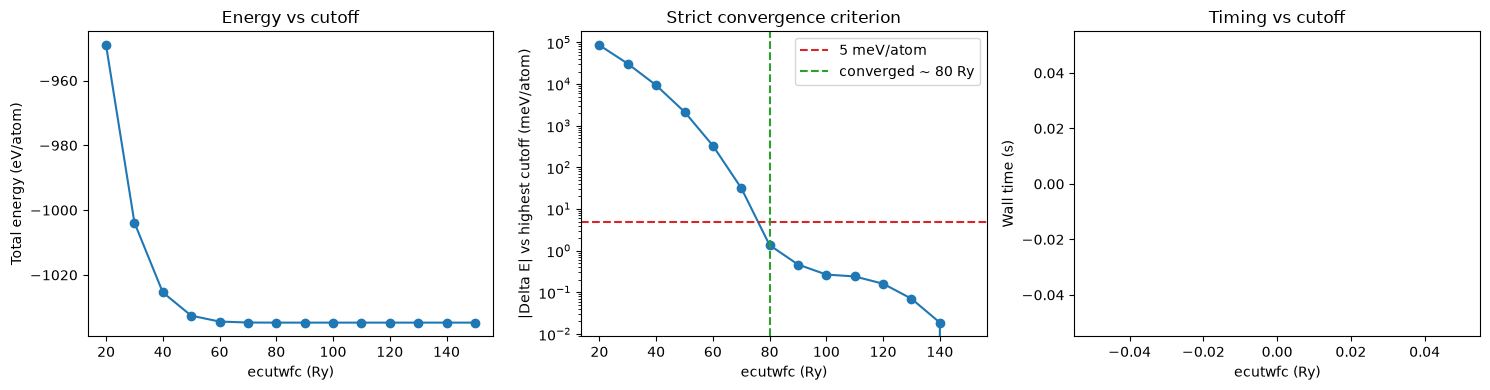

Converged cutoff: 80 Ry


In [7]:
ecut_cases = [
    (f'ecut_{e:03d}', build_mgo_input(atoms, ecutwfc=e, nk=NK_FIXED, prefix='mgo_ecut'))
    for e in ECUT_VALUES
]
ecut_results = runner.run_sweep(ecut_cases, ECUT_DIR, force_rerun=FORCE_RERUN_ECUT)

ecut   = ECUT_VALUES
energy = [r['energy_ry'] * RY_TO_EV / nat for r in ecut_results]
dE_mev = [abs(e - energy[-1]) * 1000 for e in energy]
time_s = [r['wall_s'] for r in ecut_results]

idx = first_globally_converged_index(dE_mev, ENERGY_THRESHOLD_MEV_PER_ATOM)
ecut_conv = int(ecut[idx]) if idx is not None else int(ecut[-1])

plot_ecut_convergence(ecut, energy, dE_mev, time_s, ENERGY_THRESHOLD_MEV_PER_ATOM, idx, ecut_conv)
print(f'Converged cutoff: {ecut_conv} Ry')

## Problem 2: Converging the total energy with respect to k-point sampling

Use the converged cutoff from Problem 1 for all calculations in this problem.

### Part A

Look at the number of irreducible k-points listed in the plot for each grid size. Is the number what you expect based on the nk×nk×nk grid specified in the input? Why or why not?

### Part B

Run the cell below. At what k-mesh size is the total energy converged to within 5 meV/atom?

> **Note** — Unlike the plane-wave basis, the k-point sampling energy is **not variational**: increasing the mesh does not guarantee a monotonically decreasing energy. What decreases is the absolute value of the error, estimated here as the difference |E(nk) − E(nk_dense)| relative to the densest mesh used.

### Part C

Do you see a trend in the energies with respect to mesh size? Is this what you expect? Compare to your observations in Problem 1 and explain the difference.

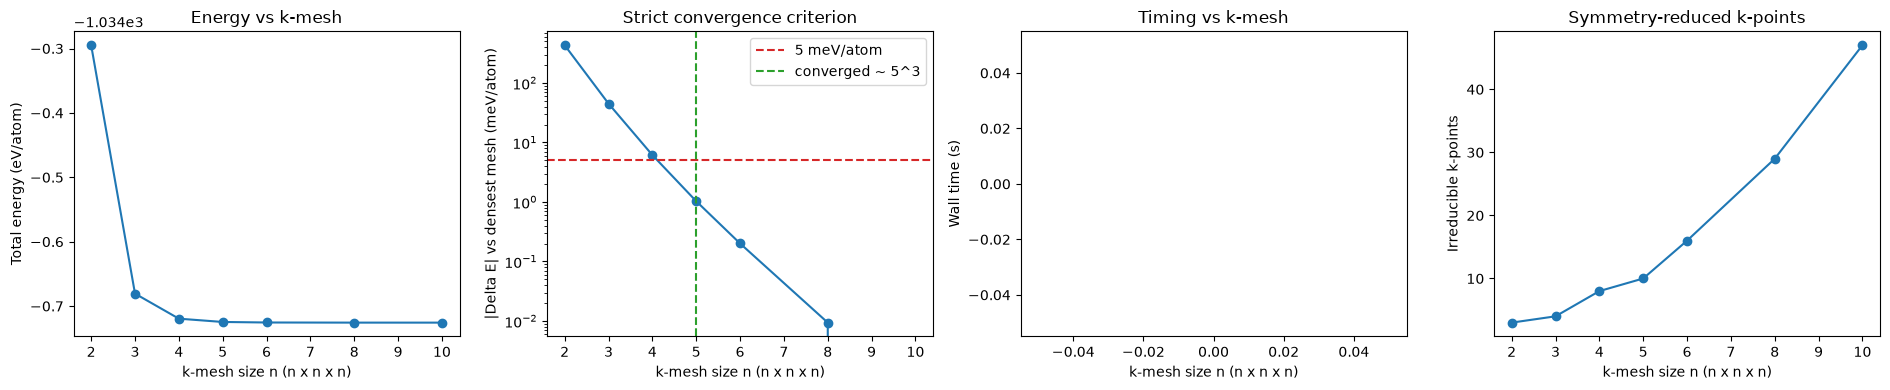

Converged k-mesh: 5x5x5


In [8]:
k_cases = [
    (f'k_{n:02d}x{n:02d}x{n:02d}', build_mgo_input(atoms, ecutwfc=ecut_conv, nk=n, prefix='mgo_kpts'))
    for n in NK_VALUES
]
k_results = runner.run_sweep(k_cases, KPTS_DIR, force_rerun=FORCE_RERUN_KPTS)

nk     = NK_VALUES
energy = [r['energy_ry'] * RY_TO_EV / nat for r in k_results]
dE_mev = [abs(e - energy[-1]) * 1000 for e in energy]
time_s = [r['wall_s'] for r in k_results]
nk_irr = [float('nan') if r['nk_irr'] is None else r['nk_irr'] for r in k_results]

idx = first_globally_converged_index(dE_mev, ENERGY_THRESHOLD_MEV_PER_ATOM)
nk_conv = int(nk[idx]) if idx is not None else int(nk[-1])

plot_k_convergence(nk, energy, dE_mev, time_s, nk_irr, ENERGY_THRESHOLD_MEV_PER_ATOM, idx, nk_conv)
print(f'Converged k-mesh: {nk_conv}x{nk_conv}x{nk_conv}')

## Problem 3: Converging forces with respect to `ecutwfc`

We are often interested in quantities other than the total energy. Here we calculate the forces acting on atoms.

### Part A

In order to calculate forces, we first need to displace an atom from its equilibrium position. Why is this necessary? What would happen if you tried to converge the forces without displacing any atoms?

### Part B

The cell below displaces atom 1 by +0.05 along the fractional *c* direction, then sweeps `ecutwfc` at a fixed 4×4×4 k-mesh. Run it and determine at what cutoff the *z*-component of the force is converged to within 10 meV/Å.

> **Note** — Forces are reported in the `pw.x` output in Ry/bohr. The code converts them to eV/Å automatically.

### Part C

Do you see a trend in the forces with respect to `ecutwfc`? If you see a trend, is this what you expect? Compare to the energy in Problem 1 and explain.

In [ ]:
atoms_displaced = atoms.copy()
pos = atoms_displaced.get_positions()
pos[DISPLACED_ATOM_INDEX_1BASED - 1, 2] += DISPLACEMENT_C_FRACTIONAL * atoms_displaced.cell.cellpar()[0]
atoms_displaced.set_positions(pos)

force_cases = [
    (f'force_ecut_{e:03d}', build_mgo_input(atoms_displaced, ecutwfc=e, nk=NK_FIXED, prefix='mgo_force_ecut'))
    for e in ECUT_VALUES
]
force_results = runner.run_sweep(
    force_cases, ECUT_DIR, force_rerun=FORCE_RERUN_FORCE_ECUT,
    collect_force_stress=True,
    atom_index_1based=DISPLACED_ATOM_INDEX_1BASED,
)

ecut   = ECUT_VALUES
fz     = [r['force_z_ev_ang'] for r in force_results]
dF_mev = [abs(f - fz[-1]) * 1000 for f in fz]
time_s = [r['wall_s'] for r in force_results]

idx = first_globally_converged_index(dF_mev, FORCE_THRESHOLD_MEV_PER_ANG)
ecut_force_conv = int(ecut[idx]) if idx is not None else int(ecut[-1])

plot_force_ecut_convergence(ecut, fz, dF_mev, time_s, FORCE_THRESHOLD_MEV_PER_ANG, idx, ecut_force_conv)
print(f'Converged cutoff (force): {ecut_force_conv} Ry')

## Problem 4: Drawing conclusions

### Part A

Based on your convergence tests, state the values of `ecutwfc` and the k-point grid you will use for all subsequent calculations.

> **Note** — Do not be overly conservative and pick unnecessarily large values. This defeats the purpose of convergence testing, which is to avoid unnecessary computational cost.

### Part B

Mathematically, what is the relationship between atomic forces and total energies? Do total energies or forces tend to converge faster with `ecutwfc`? Why?

### Part C

The pseudopotentials used here are norm-conserving. How would your results change if we used ultrasoft pseudopotentials? Which additional parameters would you need to converge in that case?